In [43]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn import datasets, tree
from sklearn.metrics import make_scorer, classification_report, confusion_matrix, f1_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

1. Завантажуємо дані набору Iris за допомогою функції load_iris() з бібліотеки sklearn.

In [7]:
dataset = datasets.load_iris()
dataset.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [13]:
df = pd.DataFrame(data=dataset['data'], columns=dataset['feature_names'])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


2. Додаємо описовий аналіз даних.

In [14]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [70]:
df_target_iris = pd.DataFrame(dataset['target'], columns =[ 'iris_type'])
df_iris_all = pd.concat([df, df_target_iris], axis=1)
df_iris_all.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),iris_type
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


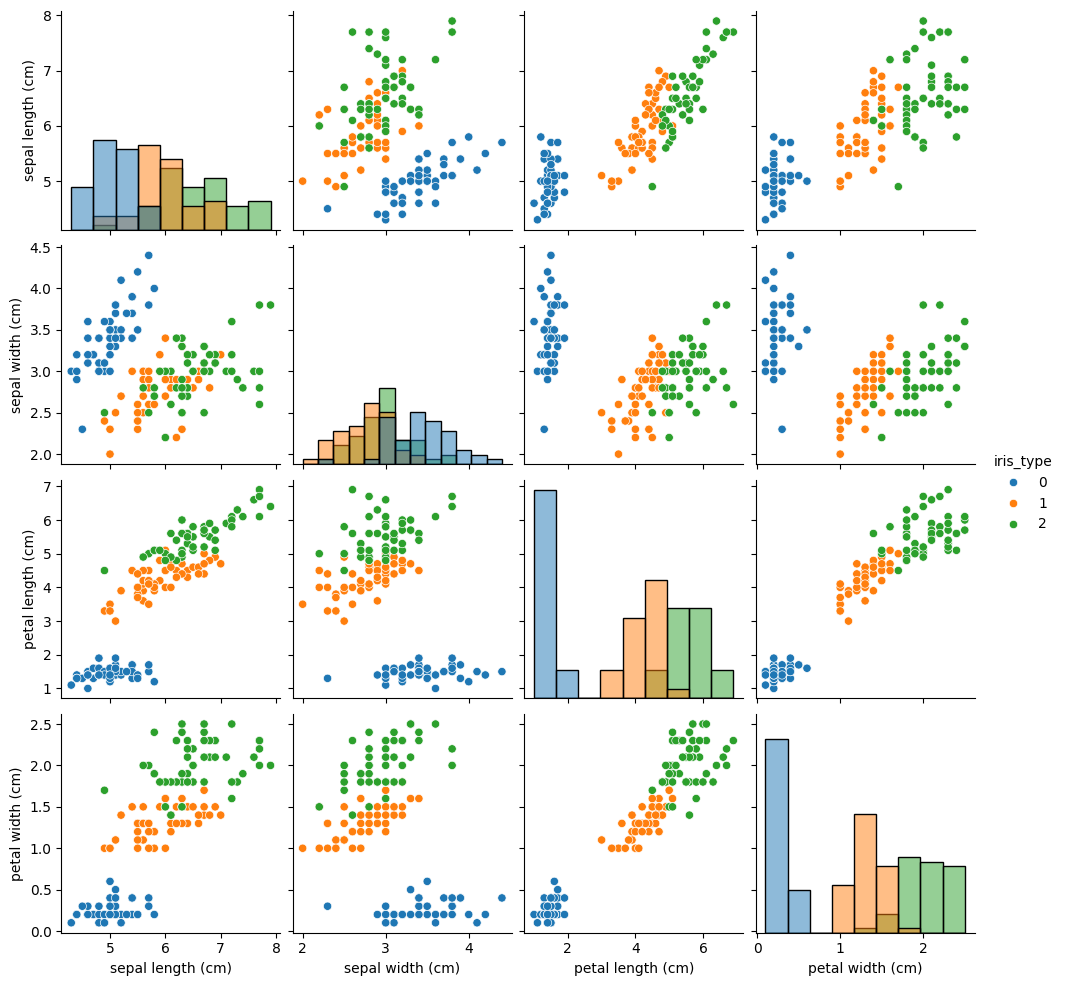

In [75]:
sns.pairplot(df_iris_all, hue='iris_type', palette= "tab10", diag_kind='hist')

In [19]:
def data_scale(dataset, scaler_type='std'):
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.preprocessing import StandardScaler
    from sklearn.preprocessing import Normalizer
    if scaler_type == 'std':
        scaler = StandardScaler()
    elif scaler_type == 'norm':
        scaler = Normalizer()
    elif scaler_type == 'minmax':
        scaler = MinMaxScaler()
    else:
        print("Scaler Type Undefined")
        return None
    scaler.fit(dataset)
    res = scaler.transform(dataset)
    return res

In [81]:
df_scaled = data_scale(df, 'std')
df_scaled = pd.DataFrame(df_scaled, columns = df.columns)
df_scaled.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


3. Виконуємо розділення набору даних для частини тренування та тестування - train_test_split() ф-ція з біблітеки sklearn.

In [82]:
X, y = df_scaled, dataset.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

4. Створюємо класифікатор на основі дерев розв'язків.

Для цього використовується функція DecisionTreeClassifier() з бібліотеки sklearn.

In [83]:
from sklearn.tree import DecisionTreeClassifier

clf_tree = DecisionTreeClassifier(max_depth=10, random_state=1)
clf_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=1)

 5. cross_val_test() для порівняння ефективності роботи класифікатора на даних для тестування та тренування у випадку використання крос-валідації.

In [84]:
def cross_test_val(model, dataX, dataY, model_type='classification', folds=5):
    cv = KFold(n_splits=folds, shuffle=True, random_state=1)
    if model_type == "regression":
        scorer={
            'mse': make_scorer(mean_squared_error),
            'r2': make_scorer(r2_score),
            'mae': make_scorer(mean_absolute_error),
            'mape': make_scorer(mean_absolute_percentage_error)
        }

    if model_type == 'classification':
        scorer = {'f1':make_scorer(f1_score, average='micro')}
    scores = cross_validate(model, dataX, dataY, scoring=scorer, cv=cv, return_train_score=True)
    return scores

In [85]:
cross_test_val(clf_tree, X, y)

{'fit_time': array([0.00469995, 0.00528622, 0.00208807, 0.00091696, 0.00082803]),
 'score_time': array([0.00665808, 0.01974773, 0.00121999, 0.00106692, 0.00127792]),
 'test_f1': array([0.96666667, 0.96666667, 0.96666667, 0.93333333, 0.83333333]),
 'train_f1': array([1., 1., 1., 1., 1.])}

6. Візуалізація отриманого дерева розв'язку за допомогою функції plot_tree() модуля tree бібліотеки sklearn.

[Text(0.5, 0.9, 'petal width (cm) <= -0.526\ngini = 0.666\nsamples = 120\nvalue = [38, 42, 40]\nclass = sepal width (cm)'),
 Text(0.4230769230769231, 0.7, 'gini = 0.0\nsamples = 38\nvalue = [38, 0, 0]\nclass = sepal length (cm)'),
 Text(0.5769230769230769, 0.7, 'petal width (cm) <= 0.725\ngini = 0.5\nsamples = 82\nvalue = [0, 42, 40]\nclass = sepal width (cm)'),
 Text(0.3076923076923077, 0.5, 'petal length (cm) <= 0.678\ngini = 0.162\nsamples = 45\nvalue = [0, 41, 4]\nclass = sepal width (cm)'),
 Text(0.15384615384615385, 0.3, 'petal width (cm) <= 0.593\ngini = 0.049\nsamples = 40\nvalue = [0, 39, 1]\nclass = sepal width (cm)'),
 Text(0.07692307692307693, 0.1, 'gini = 0.0\nsamples = 39\nvalue = [0, 39, 0]\nclass = sepal width (cm)'),
 Text(0.23076923076923078, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]\nclass = petal length (cm)'),
 Text(0.46153846153846156, 0.3, 'petal width (cm) <= 0.462\ngini = 0.48\nsamples = 5\nvalue = [0, 2, 3]\nclass = petal length (cm)'),
 Text(0.38461538

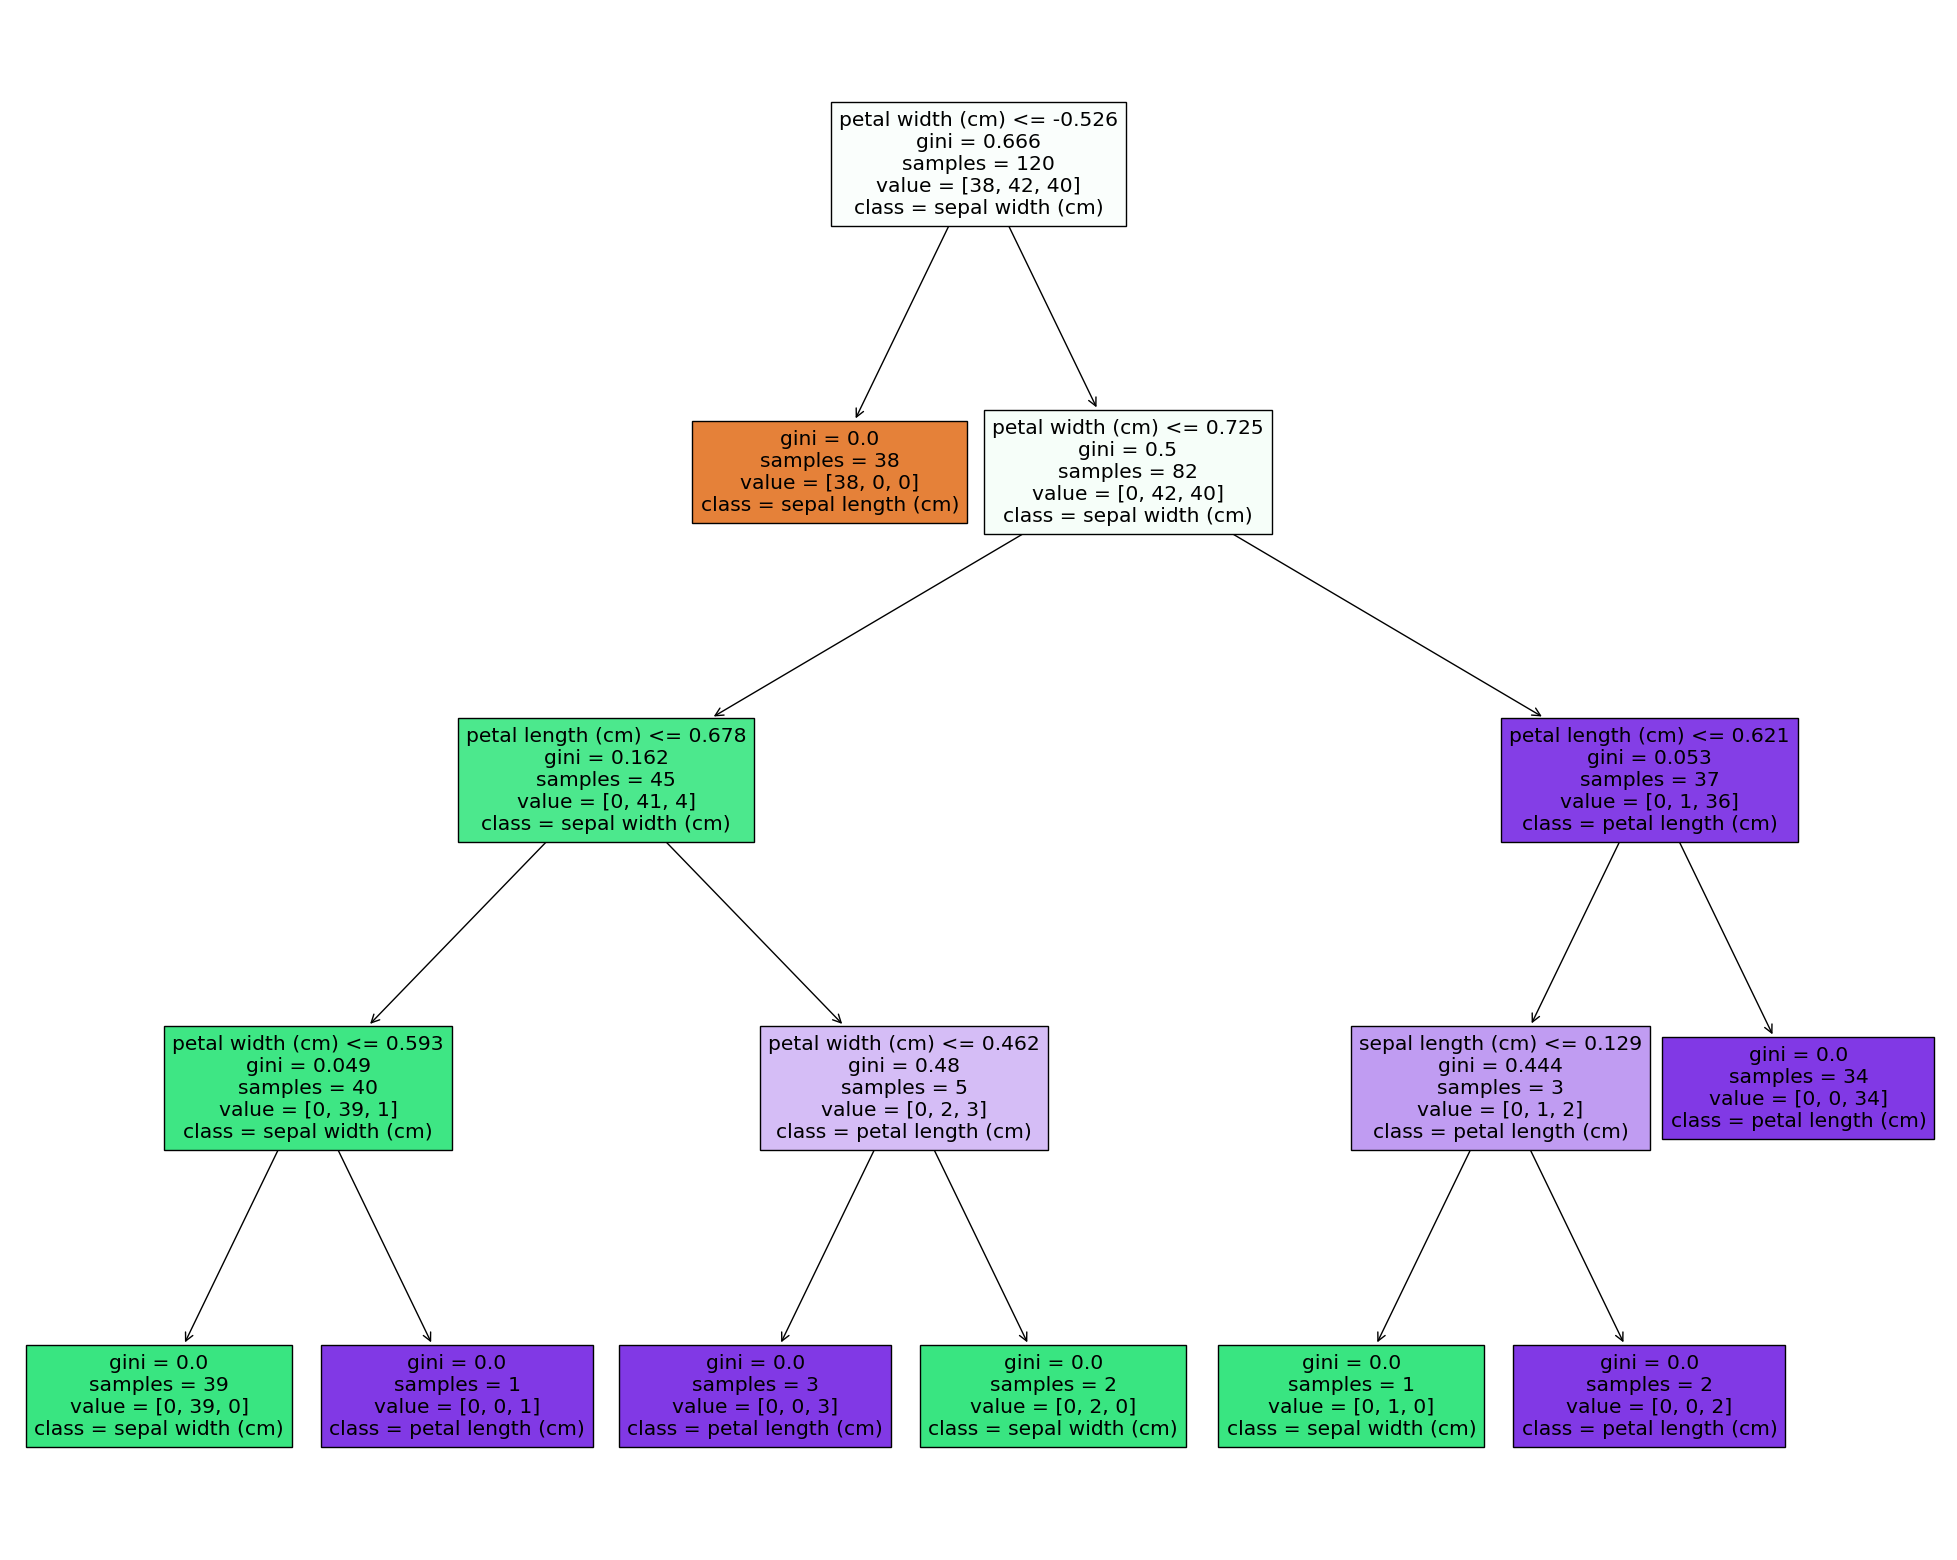

In [86]:
plt.figure(figsize=(25,20))
tree.plot_tree(
    clf_tree,
    feature_names=dataset.feature_names,
    class_names=df.columns,
    filled=True
)

7. Візуалізація границі прийняття рішення за допомогою функції DecisionBoundaryDisplay() бібліотеки sklearn.

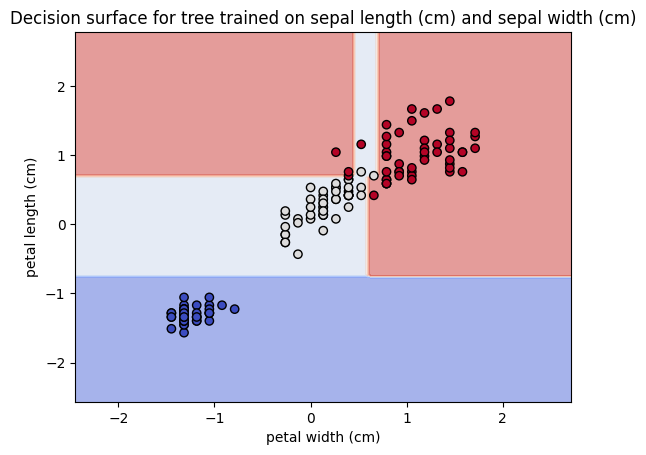

In [96]:
from sklearn.inspection import DecisionBoundaryDisplay

# choosing two features
X_train_2 = X[['petal width (cm)','petal length (cm)']]

# Creating and fitting the tree classifier
model = DecisionTreeClassifier(max_depth=4, random_state=1)
model.fit(X_train_2, y)

# Plotting the tree boundaries
display = DecisionBoundaryDisplay.from_estimator(
    model,
    X_train_2,
    response_method='predict',
    alpha=0.5,
    cmap=plt.cm.coolwarm
)

# Plotting the data points
display.ax_.scatter(
    X['petal width (cm)'], X['petal length (cm)'],
    c=df_iris_all['iris_type'],
    edgecolors='k',
    cmap=plt.cm.coolwarm
)

plt.title(f"Decision surface for tree trained on {dataset.feature_names[0]} and {dataset.feature_names[1]}")
plt.show()

8. Класифікатор випадковий ліс за допомогою функції RandomForestClassifier.

9. Точність класифікатора за допомогою функції cross_val_test().

10. Обчислювальні екперименти та оцінка оптимального набору гіперпараметрів за результатами експериментів.
